# **Animal Classification**
Manual identification of animal species in large image databases is time-consuming and prone to human error. This project addresses the challenge by building a classification model capable of distinguishing between 15 distinct animal classes. The system must be robust enough to handle various environments and lighting conditions represented within the datase

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_dir = '/content/drive/MyDrive/Animal_Classification/dataset'

# **Dataset Characteristics**
The foundation of this project is a structured dataset containing 15 folders, where each folder serves as a unique class label corresponding to the animal's name.
 *   Animal Categories: The model is trained to recognize a diverse array of species, including:
* Wild Predators: Bear, Lion, Tiger.


* Herbivores: Cow, Deer, Elephant, Giraffe, Kangaroo, Zebra
*   Domestic/Small Animals: Bird, Cat,Dog.
* Aquatic/Unique Species: Dolphin, Horse, Panda.
* Image Specifications: Every image in the dataset is standardized to a resolution of $224\times224\times3$ pixels. This consistency is crucial for ensuring that the neural network receives uniform input dimensions for processing.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Rescaling
from tensorflow.keras.applications import MobileNetV2

# **Methodology**

To achieve high accuracy with a relatively small dataset, the project utilizes Transfer Learning. This involves taking a pre-trained Neural Network—which has already learned general features like edges and textures from millions of images—and fine-tuning it to recognize the specific features of our 15 animal classes. This approach provides a "better learning experience" and significantly reduces the computational time required for training.


Loading training data...
Found 1945 files belonging to 15 classes.
Using 1556 files for training.
Loading validation data...
Found 1945 files belonging to 15 classes.
Using 389 files for validation.
Detected classes: ['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse', 'Kangaroo', 'Lion', 'Panda', 'Tiger', 'Zebra']

Starting Training...
Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 254s 5s/step - accuracy: 0.6793 - loss: 1.1777 - val_accuracy: 0.9254 - val_loss: 0.3055
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9145 - loss: 0.2934 - val_accuracy: 0.9486 - val_loss: 0.2257
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9319 - loss: 0.2322 - val_accuracy: 0.9306 - val_loss: 0.2420
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9447 - loss: 0.1749 - val_accuracy: 0.9409 - val_loss: 0.1987
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9518 - loss: 0.1482 - val_accuracy: 0.9512 - val_los

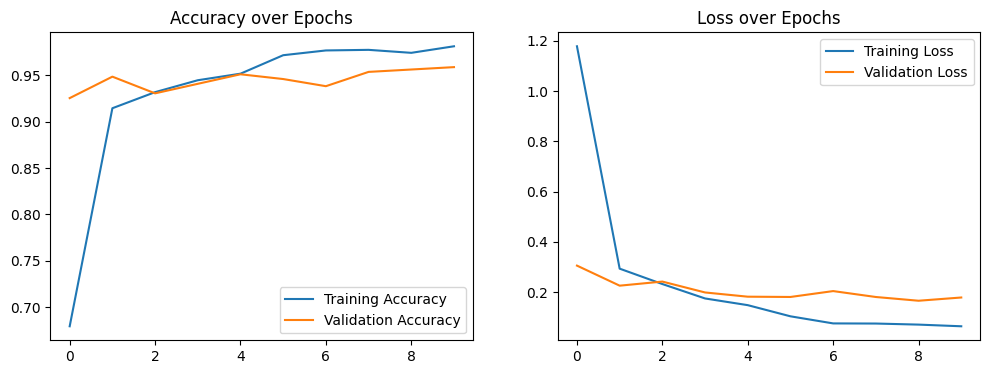


--- Project Complete and Model Saved! ---


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import os

# --- 1. SETTINGS & PATHS ---
# Replace 'path/to/your/dataset' with the actual folder containing the 15 animal folders
IMG_SIZE = (224, 224) # Specified in PDF
BATCH_SIZE = 32

# --- 2. LOAD THE DATASET ---
# This automatically labels images based on the 15 folder names [cite: 8, 9]
print("Loading training data...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Loading validation data...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Identify the 15 classes from the directory [cite: 9]
class_names = train_ds.class_names
print(f"Detected classes: {class_names}")

# --- 3. CONFIGURE FOR PERFORMANCE ---
# Buffered prefetching to load data from disk without I/O blocking
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# --- 4. BUILD THE MODEL (Transfer Learning) ---
# Using MobileNetV2 as recommended for a "better learning experience"
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze pre-trained weights

model = models.Sequential([
    # Data Augmentation (Optional but helps accuracy)
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),

    # Preprocessing: MobileNetV2 expects values in range [-1, 1]
    layers.Rescaling(1./127.5, offset=-1),

    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2), # Prevents overfitting
    layers.Dense(128, activation='relu'),
    layers.Dense(15, activation='softmax') # 15 classes for the 15 animals [cite: 7, 9]
])

# --- 5. COMPILE & TRAIN ---
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nStarting Training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10 # Increased to 10 for better convergence
)

# --- 6. VISUALIZE RESULTS ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

# --- 7. SAVE THE MODEL ---
model.save('animal_classifier_model.h5')
print("\n--- Project Complete and Model Saved! ---")

In [ ]:
import json
from google.colab import drive

drive.mount('/content/drive')

MODEL_NAME = "animal_classifier_mobilenetv2"
SAVE_PATH = "/content/drive/MyDrive/ML_Models/"

import os
os.makedirs(SAVE_PATH, exist_ok=True)

# Save model
model.save(f"{SAVE_PATH}{MODEL_NAME}.h5")

# Save class names (critical!)
with open(f"{SAVE_PATH}{MODEL_NAME}_classes.json", "w") as f:
    json.dump(class_names, f)

print(f"Model saved: {MODEL_NAME}.h5")
print(f"Classes saved: {class_names}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved: animal_classifier_mobilenetv2.h5
Classes saved: ['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse', 'Kangaroo', 'Lion', 'Panda', 'Tiger', 'Zebra']


# **Model Loading**

In [ ]:
import tensorflow as tf
import json
from google.colab import drive

drive.mount('/content/drive')

MODEL_NAME = "animal_classifier_mobilenetv2"
SAVE_PATH = "/content/drive/MyDrive/ML_Models/"

model = tf.keras.models.load_model(f"{SAVE_PATH}{MODEL_NAME}.h5")

with open(f"{SAVE_PATH}{MODEL_NAME}_classes.json", "r") as f:
    class_names = json.load(f)

print("Model loaded ")
print("Classes:", class_names)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Model loaded 
Classes: ['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse', 'Kangaroo', 'Lion', 'Panda', 'Tiger', 'Zebra']


# **Testing the model**

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import files

uploaded = files.upload()  # Upload your test image
IMG_SIZE = (224, 224)

def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Must match training preprocessing
    img_array = (img_array / 127.5) - 1

    predictions = model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100

    print(f"Predicted Animal : {class_names[predicted_index]}")
    print(f"Confidence       : {confidence:.2f}%")

predict_image(list(uploaded.keys())[0])

Saving puppy-1047521_1280.jpg to puppy-1047521_1280.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted Animal : Dog
Confidence       : 43.23%


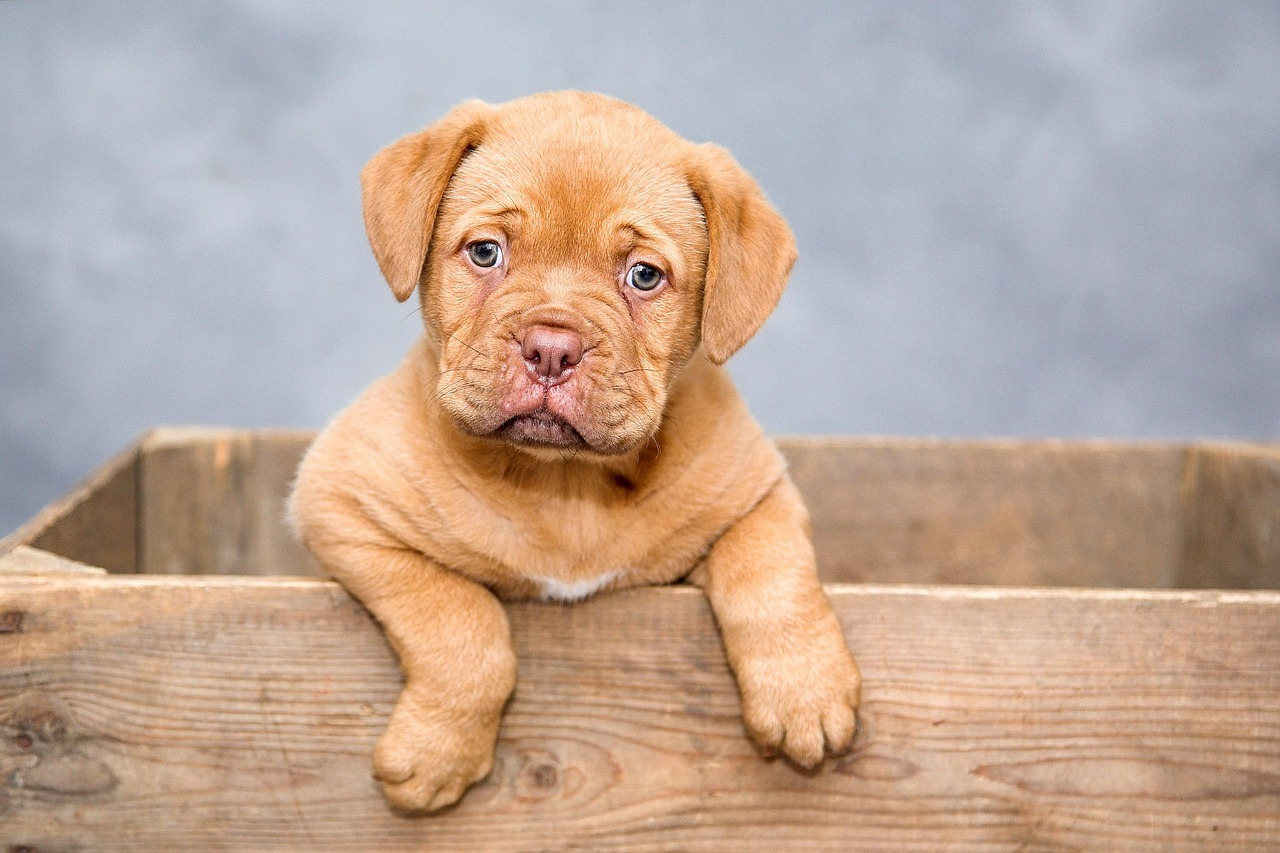